# Does vertical shear produce rotation-dependent EAC eddy tilt?

This notebook tests the mechanism suggested by Chao and Shaw (1998): differential advection produces an along-flow displacement, while interaction between the ambient flow and eddy rotation produces a transverse response whose sign reverses with rotation. The Arctic result is a hypothesis to test, not a sign convention to impose on the Southern Hemisphere EAC.

The existing `TiltDir` and `TiltDis` are the authoritative coherent tilt measurements. They are **never recomputed from raw centre positions**. `TiltDir` points from the deep fitted centre toward the shallow fitted centre, so all shear vectors use the matching **upper minus deep** convention. Positive cross-shear displacement is left of that vector.

Primary prediction: AE and CE should share an along-shear response but have opposite cross-shear responses. The most specific test is the `shear magnitude × Cyc` interaction, followed by a lagged test asking whether current shear predicts subsequent change in the measured tilt vector.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError('Launch from seacofs_eddy_tilt_analysis or one of its subfolders.')
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
MECHANISM_ROOT = ANALYSIS_ROOT / 'tilt_mechanisms'
THIS_ROOT = ANALYSIS_ROOT / 'shear_lift_tilt'
for folder in (ANALYSIS_ROOT, FLOW_ROOT, MECHANISM_ROOT, THIS_ROOT):
    if str(folder) not in sys.path:
        sys.path.insert(0, str(folder))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
from shear_lift_tools import (add_lagged_tilt_change, add_shear_relative_tilt,
                              add_shear_vectors, eddy_equal_binned_summary)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
# Predefined analysis choices. Change here, not after inspecting significance.
MIN_TILT_KM = 5.0
MIN_SHEAR_MS = 0.005
PRIMARY_FAMILY = 'clim'
PRIMARY_DEFINITION = 'upper_deep'  # 0-200 m minus 200-500 m
FAMILIES = ('clim', 'full')
DEFINITIONS = {
    'upper_deep': '0-200 m minus 200-500 m',
    'surface_deep': 'surface minus 200-500 m',
}
LAGS_DAYS = (1, 3, 5, 10)
COLORS = {'AE': 'firebrick', 'CE': 'royalblue'}

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths)
eddies = tilt.add_region_labels(eddies, grid)
background = load_background_cache(BackgroundConfig()).drop(columns=['ic', 'jc'], errors='ignore')
required = {f'{family}_{depth}_{component}_ms' for family in FAMILIES
            for depth in ('surface', '200', '500') for component in ('east', 'north')}
if missing := required - set(background.columns):
    raise RuntimeError(f'Background cache missing {sorted(missing)}; run 01_build_background_cache.ipynb.')
if background.duplicated(['Eddy', 'Day']).any():
    raise ValueError('Background cache has duplicate Eddy-Day rows.')
data = eddies.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
data = add_shear_vectors(data, families=FAMILIES)
data = data.loc[data.TiltDis.ge(MIN_TILT_KM)].sort_values(['Eddy', 'Day']).copy()
if 'lat' not in data:
    ii = data.ic.astype(int).clip(0, grid.lat_rho.shape[0] - 1)
    jj = data.jc.astype(int).clip(0, grid.lat_rho.shape[1] - 1)
    data['lat'] = grid.lat_rho[ii, jj]
display(data.groupby('Cyc').agg(observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
                                   median_tilt_km=('TiltDis', 'median'), median_lat=('lat', 'median')).round(2))

,observations,eddies,median_tilt_km,median_lat
Cyc,,,,
AE,49268,1421,21.42,-34.90
CE,46397,1530,17.95,-33.62


## 1. Express the measured tilt in local shear coordinates

For shear unit vector $\hat{s}$, the notebook calculates $T_{\parallel}=\mathbf{T}\cdot\hat{s}$ and $T_{\mathrm{left}}=\mathbf{T}\cdot(\hat{k}\times\hat{s})$. Fractions divide these projections by `TiltDis`, separating direction from tilt magnitude. No polarity multiplier is applied.

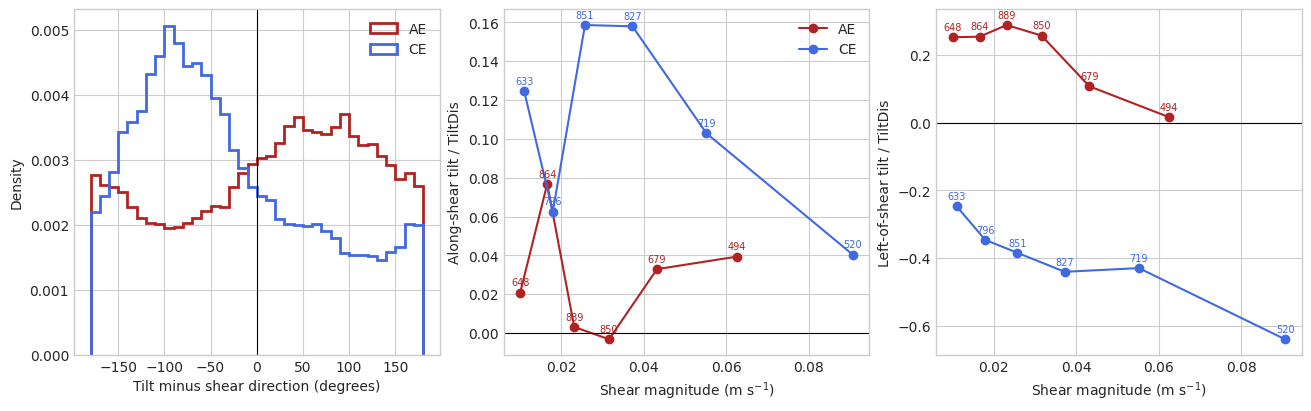

Numbers beside points are eddies, not observations.


In [3]:
relative_tables = {}
for family in FAMILIES:
    for definition in DEFINITIONS:
        prefix = f'{family}_{definition}'
        relative_tables[prefix] = add_shear_relative_tilt(
            data, f'{prefix}_east_ms', f'{prefix}_north_ms',
            prefix=prefix, minimum_shear_ms=MIN_SHEAR_MS,
        )
primary_prefix = f'{PRIMARY_FAMILY}_{PRIMARY_DEFINITION}'
primary = relative_tables[primary_prefix]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for cyc in ('AE', 'CE'):
    q = primary.loc[primary.Cyc.eq(cyc)]
    axes[0].hist(q[f'{primary_prefix}_offset_deg'].dropna(), bins=np.arange(-180, 181, 10),
                 density=True, histtype='step', lw=2, color=COLORS[cyc], label=cyc)
    for ax, response, ylabel in (
        (axes[1], f'{primary_prefix}_tilt_parallel_fraction', 'Along-shear tilt / TiltDis'),
        (axes[2], f'{primary_prefix}_tilt_left_fraction', 'Left-of-shear tilt / TiltDis')):
        summary = eddy_equal_binned_summary(q, f'{primary_prefix}_shear_mag_ms', response)
        ax.plot(summary.x, summary.y, 'o-', color=COLORS[cyc], label=cyc)
        for row in summary.itertuples():
            ax.annotate(str(row.eddies), (row.x, row.y), xytext=(0, 5),
                        textcoords='offset points', ha='center', fontsize=7, color=COLORS[cyc])
axes[0].axvline(0, color='k', lw=.8); axes[0].set(xlabel='Tilt minus shear direction (degrees)', ylabel='Density')
for ax in axes[1:]:
    ax.axhline(0, color='k', lw=.8); ax.set_xlabel('Shear magnitude (m s$^{-1}$)')
axes[1].set_ylabel('Along-shear tilt / TiltDis'); axes[2].set_ylabel('Left-of-shear tilt / TiltDis')
axes[0].legend(); axes[1].legend(); plt.show()
print('Numbers beside points are eddies, not observations.')

## 2. Clustered same-day mechanism models

The directional models use normalized projections, while the kilometre models retain amplitude. GEE clusters repeated days by eddy and adjusts flexibly for latitude. The mechanism-specific coefficient is the difference between the CE and AE shear-magnitude slopes. A significant interaction alone is not sufficient: the fitted polarity-specific slopes should also have opposing signs for the cross-shear response.

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p
0,same_day,clim_upper_deep,tilt_parallel_fraction,AE,48153,1420,-0.8645,-1.7501,0.0210,0.0557,0.4684
1,same_day,clim_upper_deep,tilt_parallel_fraction,CE,45269,1529,-0.5024,-0.9461,-0.0586,0.0265,0.4684
2,same_day,clim_upper_deep,tilt_left_fraction,AE,48153,1420,-2.0496,-2.9357,-1.1634,0.0000,0.8546
3,same_day,clim_upper_deep,tilt_left_fraction,CE,45269,1529,-2.1415,-2.5890,-1.6940,0.0000,0.8546
4,same_day,clim_upper_deep,tilt_parallel_km,AE,48153,1420,-22.5930,-51.7802,6.5942,0.1292,0.9518
5,same_day,clim_upper_deep,tilt_parallel_km,CE,45269,1529,-23.5808,-37.0635,-10.0982,0.0006,0.9518
6,same_day,clim_upper_deep,tilt_left_km,AE,48153,1420,-72.9894,-100.8685,-45.1104,0.0000,0.0938
7,same_day,clim_upper_deep,tilt_left_km,CE,45269,1529,-46.3854,-60.4253,-32.3454,0.0000,0.0938
8,same_day,clim_surface_deep,tilt_parallel_fraction,AE,49111,1421,-0.4359,-1.1305,0.2586,0.2186,0.5411
9,same_day,clim_surface_deep,tilt_parallel_fraction,CE,46247,1530,-0.1950,-0.5473,0.1572,0.2779,0.5411


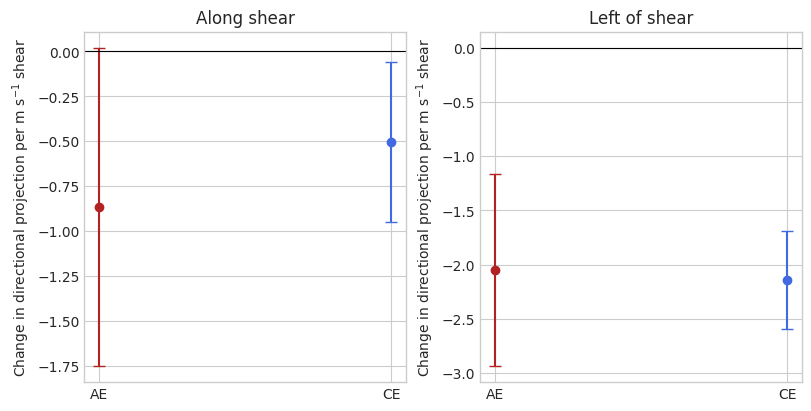

In [4]:
def fit_shear_gee(frame, prefix, response_suffix, analysis):
    mag = f'{prefix}_shear_mag_ms'; response = f'{prefix}_{response_suffix}'
    columns = ['Eddy', 'Cyc', 'lat', 'Region', mag, response]
    use = frame[columns].replace([np.inf, -np.inf], np.nan).dropna().rename(
        columns={mag: 'shear_mag_ms', response: 'response'})
    if use.Cyc.nunique() < 2 or use.Eddy.nunique() < 10:
        return None, []
    fit = smf.gee('response ~ shear_mag_ms * C(Cyc) + bs(lat, df=4)',
                  groups='Eddy', data=use).fit()
    names = list(fit.params.index); rows = []
    for cyc in ('AE', 'CE'):
        contrast = np.zeros(len(names)); contrast[names.index('shear_mag_ms')] = 1
        interaction = 'shear_mag_ms:C(Cyc)[T.CE]'
        if cyc == 'CE' and interaction in names:
            contrast[names.index(interaction)] = 1
        test = fit.t_test(contrast); ci = np.asarray(test.conf_int()).ravel()
        part = use.loc[use.Cyc.eq(cyc)]
        rows.append(dict(analysis=analysis, prefix=prefix, response=response_suffix, Cyc=cyc,
                         observations=len(part), eddies=part.Eddy.nunique(),
                         slope=float(np.asarray(test.effect).item()), ci_low=float(ci[0]),
                         ci_high=float(ci[1]), p_value=float(np.asarray(test.pvalue).item()),
                         interaction_p=float(fit.pvalues.get(interaction, np.nan))))
    return fit, rows

same_day_rows = []
for prefix, frame in relative_tables.items():
    for suffix in ('tilt_parallel_fraction', 'tilt_left_fraction',
                   'tilt_parallel_km', 'tilt_left_km'):
        _, rows = fit_shear_gee(frame, prefix, suffix, 'same_day')
        same_day_rows.extend(rows)
same_day_models = pd.DataFrame(same_day_rows)
display(same_day_models.round(4))

shown = same_day_models.query("prefix == @primary_prefix and response in ['tilt_parallel_fraction','tilt_left_fraction']")
fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
for ax, suffix, title in zip(axes, ('tilt_parallel_fraction', 'tilt_left_fraction'),
                             ('Along shear', 'Left of shear')):
    q = shown.loc[shown.response.eq(suffix)]
    for x, cyc in enumerate(('AE', 'CE')):
        row = q.loc[q.Cyc.eq(cyc)].iloc[0]
        ax.errorbar(x, row.slope, [[row.slope-row.ci_low], [row.ci_high-row.slope]],
                    fmt='o', capsize=4, color=COLORS[cyc])
    ax.axhline(0, color='k', lw=.8); ax.set_xticks((0, 1), ('AE', 'CE'))
    ax.set(title=title, ylabel='Change in directional projection per m s$^{-1}$ shear')
plt.show()

## 3. Does shear precede a change in coherent tilt?

These are exact 1, 3, 5 and 10-day matches within the same eddy. Each response is the future `TiltDir`/`TiltDis` vector minus the current `TiltDir`/`TiltDis` vector, projected onto the **current** shear basis. This retains the coherent tilt estimates at both endpoints and avoids differencing raw fitted centres.

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p
0,lag_1d_parallel,clim_upper_deep,lag_response,AE,45644,1417,5.6727,2.6954,8.6500,0.0002,0.0000
1,lag_1d_parallel,clim_upper_deep,lag_response,CE,42814,1527,-4.2830,-5.7716,-2.7944,0.0000,0.0000
2,lag_1d_left,clim_upper_deep,lag_response,AE,45644,1417,-1.6000,-4.2598,1.0598,0.2384,0.0047
3,lag_1d_left,clim_upper_deep,lag_response,CE,42814,1527,2.5906,1.3134,3.8679,0.0001,0.0047
4,lag_3d_parallel,clim_upper_deep,lag_response,AE,41834,1408,6.0124,3.1695,8.8553,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
59,lag_5d_left,full_surface_deep,lag_response,CE,35672,1505,3.1452,2.0148,4.2756,0.0000,0.0049
60,lag_10d_parallel,full_surface_deep,lag_response,AE,32846,1358,3.6763,1.5000,5.8526,0.0009,0.0004
61,lag_10d_parallel,full_surface_deep,lag_response,CE,28880,1467,-0.6181,-1.6885,0.4523,0.2577,0.0004
62,lag_10d_left,full_surface_deep,lag_response,AE,32846,1358,-1.0692,-3.0634,0.9249,0.2933,0.0001


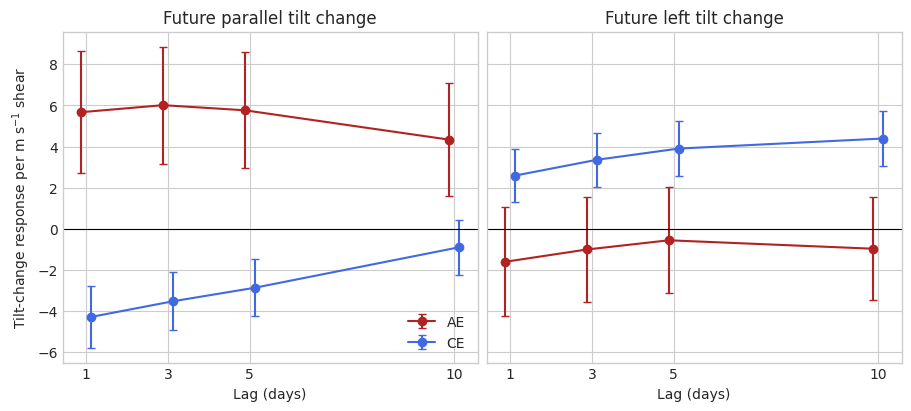

In [5]:
lag_rows = []
for prefix, frame in relative_tables.items():
    for lag in LAGS_DAYS:
        lagged = add_lagged_tilt_change(frame, lag_days=lag, prefix=prefix)
        for direction in ('parallel', 'left'):
            response = f'{prefix}_{lag}d_dtilt_{direction}_km_day'
            model_frame = lagged.rename(columns={response: f'{prefix}_lag_response'})
            _, rows = fit_shear_gee(model_frame, prefix, 'lag_response', f'lag_{lag}d_{direction}')
            lag_rows.extend(rows)
lag_models = pd.DataFrame(lag_rows)
display(lag_models.round(4))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True, constrained_layout=True)
for ax, direction in zip(axes, ('parallel', 'left')):
    q = lag_models.loc[(lag_models.prefix == primary_prefix) &
                       lag_models.analysis.str.endswith(direction)]
    for offset, cyc in zip((-.12, .12), ('AE', 'CE')):
        part = q.loc[q.Cyc.eq(cyc)].copy()
        part['lag'] = part.analysis.str.extract(r'lag_(\d+)d')[0].astype(int)
        part = part.sort_values('lag')
        axes_x = part.lag + offset
        ax.errorbar(axes_x, part.slope, [part.slope-part.ci_low, part.ci_high-part.slope],
                    fmt='o-', capsize=3, color=COLORS[cyc], label=cyc)
    ax.axhline(0, color='k', lw=.8); ax.set_xticks(LAGS_DAYS)
    ax.set(xlabel='Lag (days)', title=f'Future {direction} tilt change')
axes[0].set_ylabel('Tilt-change response per m s$^{-1}$ shear')
axes[0].legend(); plt.show()

## 4. Does the shear-relative response explain poleward/equatorward tilt?

A rotation-dependent transverse mechanism explains the geographic AE-equatorward/CE-poleward result only if the local left/right shear normals project consistently onto north/south. This section compares those projections by latitude and region, then audits whether the conclusions survive all four predefined shear estimates.

observations  eddies  median_left_normal_poleward  \
Region Cyc                                                      
D1     AE          20873     686                       -0.864   
       CE          13996     612                       -0.839   
D2     AE           6751     281                       -0.975   
       CE           4987     213                       -0.978   
S1     AE           2118     164                       -0.090   
       CE           3641     215                        0.063   
S2     AE           4188     227                        0.024   
       CE           5798     357                        0.229   
U1     AE           6869     300                       -0.449   
       CE           7067     301                       -0.448   
U2     AE           8469     339                       -0.876   
       CE          10908     408                       -0.855   

            median_tilt_poleward_km  
Region Cyc                           
D1     AE                    -5.991  
       CE                     5.492  
D2     AE                    -8.816  
       CE                     5.244  
S1     AE                    -7.045  
       CE                    -1.345  
S2     AE                    -7.590  
       CE                     1.145  
U1     AE                   -10.302  
       CE                    11.130  
U2     AE                   -11.547  
       CE                     6.784

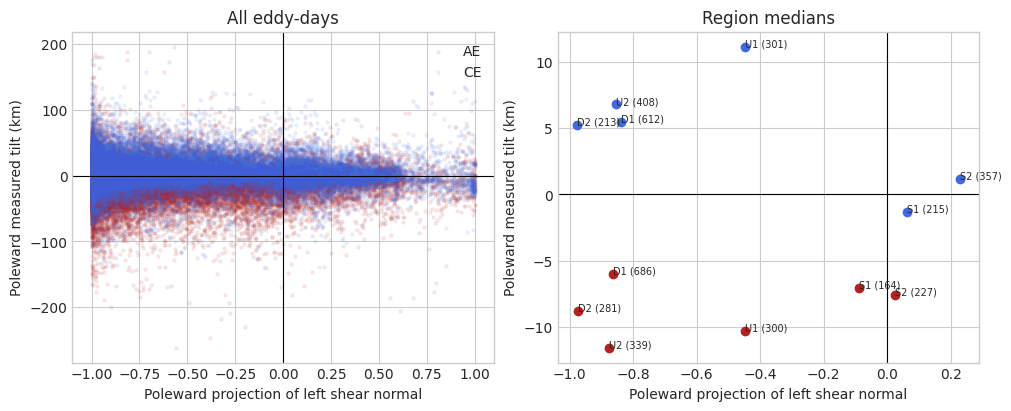

,analysis,prefix,response,Cyc,observations,eddies,slope,ci_low,ci_high,p_value,interaction_p,opposite_cross_slopes
10,same_day,clim_surface_deep,tilt_left_fraction,AE,49111,1421,-1.1089,-1.7559,-0.4619,0.0008,0.0156,False
11,same_day,clim_surface_deep,tilt_left_fraction,CE,46247,1530,-2.0039,-2.3368,-1.6710,0.0000,0.0156,False
2,same_day,clim_upper_deep,tilt_left_fraction,AE,48153,1420,-2.0496,-2.9357,-1.1634,0.0000,0.8546,False
3,same_day,clim_upper_deep,tilt_left_fraction,CE,45269,1529,-2.1415,-2.5890,-1.6940,0.0000,0.8546,False
26,same_day,full_surface_deep,tilt_left_fraction,AE,48777,1420,-1.7865,-2.4865,-1.0865,0.0000,0.6578,False
27,same_day,full_surface_deep,tilt_left_fraction,CE,45521,1530,-1.6119,-1.9465,-1.2773,0.0000,0.6578,False
18,same_day,full_upper_deep,tilt_left_fraction,AE,48431,1418,-2.8324,-3.7802,-1.8846,0.0000,0.0409,False
19,same_day,full_upper_deep,tilt_left_fraction,CE,45255,1527,-1.7446,-2.1951,-1.2941,0.0000,0.0409,False
8,same_day,clim_surface_deep,tilt_parallel_fraction,AE,49111,1421,-0.4359,-1.1305,0.2586,0.2186,0.5411,False
9,same_day,clim_surface_deep,tilt_parallel_fraction,CE,46247,1530,-0.1950,-0.5473,0.1572,0.2779,0.5411,False


In [6]:
projection = primary.copy()
projection[f'{primary_prefix}_left_normal_north'] = projection[f'{primary_prefix}_unit_east']
projection['poleward_sign'] = np.sign(projection.lat)
projection[f'{primary_prefix}_left_normal_poleward'] = (
    projection[f'{primary_prefix}_left_normal_north'] * projection.poleward_sign)
projection['tilt_poleward_km'] = projection.tilt_north_km * projection.poleward_sign
display(projection.groupby(['Region', 'Cyc'], observed=True).agg(
    observations=('Eddy', 'size'), eddies=('Eddy', 'nunique'),
    median_left_normal_poleward=(f'{primary_prefix}_left_normal_poleward', 'median'),
    median_tilt_poleward_km=('tilt_poleward_km', 'median')).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for cyc in ('AE', 'CE'):
    q = projection.loc[projection.Cyc.eq(cyc)]
    axes[0].scatter(q[f'{primary_prefix}_left_normal_poleward'], q['tilt_poleward_km'],
                    s=5, alpha=.08, color=COLORS[cyc], label=cyc)
    region = q.groupby('Region', observed=True).agg(
        normal=(f'{primary_prefix}_left_normal_poleward', 'median'),
        tilt=('tilt_poleward_km', 'median'), eddies=('Eddy', 'nunique')).reset_index()
    axes[1].plot(region.normal, region.tilt, 'o', color=COLORS[cyc], label=cyc)
    for row in region.itertuples():
        axes[1].annotate(f'{row.Region} ({row.eddies})', (row.normal, row.tilt), fontsize=7)
for ax in axes:
    ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
    ax.set(xlabel='Poleward projection of left shear normal', ylabel='Poleward measured tilt (km)')
axes[0].set_title('All eddy-days'); axes[1].set_title('Region medians'); axes[0].legend(); plt.show()

audit = same_day_models.loc[same_day_models.response.isin(
    ['tilt_parallel_fraction', 'tilt_left_fraction'])].copy()
audit['opposite_cross_slopes'] = audit.groupby(['prefix', 'response']).slope.transform(
    lambda x: np.sign(x.iloc[0]) != np.sign(x.iloc[-1]) if len(x) == 2 else False)
display(audit.sort_values(['response', 'prefix', 'Cyc']).round(4))

## Interpretation checklist

Support for a Chao-Shaw-like contribution requires a coherent pattern, not one small p-value:

1. AE and CE have similar-signed along-shear responses.
2. Their cross-shear slopes have opposite signs and the interaction is supported.
3. The reversal survives the primary 0-200 minus 200-500 m climatological definition and reasonable sensitivity definitions.
4. Current shear predicts later cross-shear changes in the measured `TiltDir`/`TiltDis` vector.
5. The transverse shear normals project appropriately onto the observed poleward/equatorward directions.

If the response is geographic poleward/equatorward but not organized relative to local shear, beta or topographic PV forcing is a better directional explanation. If shear-relative and PV-relative relationships both survive joint controls, shear may provide the immediate deformation while the larger-scale PV environment selects the preferred orientation. The analysis is observational and should be described as consistency with a rotation-dependent transverse response, not direct measurement of a lift force.